# 01 - Bond Pricing Basics
End-to-end walkthrough for clean/dirty price, yield, duration, convexity, and DV01 using the toolkit APIs.

### What this notebook covers
1. Build a representative Treasury bond object.
2. Evaluate pricing and risk metrics across a yield grid.
3. Visualize price-yield and DV01 sensitivity.
4. Back out implied yield from an observed clean price.

In [5]:
from __future__ import annotations
from datetime import date
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from fixed_income_toolkit.pricing import price_bond
from fixed_income_toolkit.types import BondSpec

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

### Step 1: Define instrument and run yield sensitivity
We create a 10Y Treasury-style bond and reprice it across a yield grid to observe non-linear price and risk behavior.

In [6]:
bond = BondSpec(
    id="UST_10Y_EXAMPLE",
    face=100.0,
    coupon=0.045,
    maturity=date(2036, 9, 15),
    settlement=date(2026, 9, 15),
    frequency=2,
)

yield_grid = [0.035, 0.040, 0.045, 0.050, 0.055]
rows = []
for y in yield_grid:
    a = price_bond(bond, ytm=y)
    rows.append({
        "yield": y,
        "clean_price": a.clean_price,
        "dirty_price": a.dirty_price,
        "modified_duration": a.modified_duration,
        "convexity": a.convexity,
        "dv01": a.dv01,
    })

pricing_df = pd.DataFrame(rows)
pricing_df

,yield,clean_price,dirty_price,modified_duration,convexity,dv01
0,0.035000,108.376441,108.376441,8.105954,78.026287,0.087849
1,0.040000,104.087858,104.087858,8.044129,77.117932,0.083730
2,0.045000,100.000000,100.000000,7.981856,76.208997,0.079819
3,0.050000,96.102709,96.102709,7.919141,75.299581,0.076105
4,0.055000,92.386374,92.386374,7.855991,74.389791,0.072579


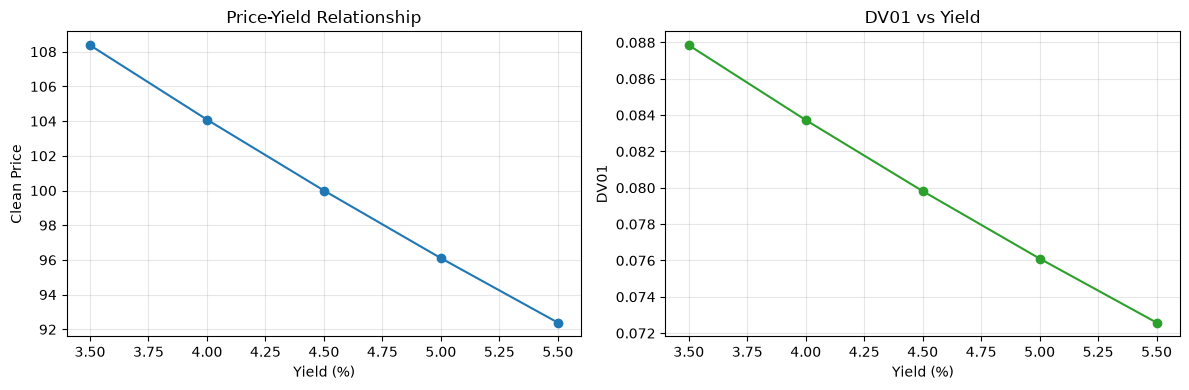

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(pricing_df["yield"] * 100, pricing_df["clean_price"], marker="o")
ax[0].set_title("Price-Yield Relationship")
ax[0].set_xlabel("Yield (%)")
ax[0].set_ylabel("Clean Price")
ax[0].grid(alpha=0.3)

ax[1].plot(pricing_df["yield"] * 100, pricing_df["dv01"], marker="o", color="tab:green")
ax[1].set_title("DV01 vs Yield")
ax[1].set_xlabel("Yield (%)")
ax[1].set_ylabel("DV01")
ax[1].grid(alpha=0.3)
plt.tight_layout()

In [8]:
target_clean_price = 102.0
implied = price_bond(bond, clean_price=target_clean_price)
pd.Series({
    "input_clean_price": target_clean_price,
    "implied_yield": implied.ytm,
    "recomputed_clean_price": implied.clean_price,
    "dv01": implied.dv01,
})

input_clean_price        102.000000
implied_yield              0.042524
recomputed_clean_price   102.000000
dv01                       0.081730
dtype: float64